<a href="https://colab.research.google.com/github/afiqgib/ML/blob/main/MILESTONE_1_to_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MACHINE LEARNING DATA PIPELINE
## COMBINED MILESTONE 1, 2, 3, 4 AND 5
### Student Performance Dataset (ARFF)

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. IMPORT LIBRARIES

In [40]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# MILESTONE 1 & 2: DATA PIPELINE AND BASELINE MODEL

## 2. LOAD DATASET

In [41]:
file_path = r"data/CEE_DATA.arff"

try:
    data, meta = arff.loadarff(file_path)
    df_original = pd.DataFrame(data)
    print("Dataset successfully loaded!\n")
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found.")
    exit()

Error: The file at data/CEE_DATA.arff was not found.


## 3. DATA CLEANING

In [42]:
for col in df_original.columns:
    if df_original[col].dtype == object:
        df_original[col] = df_original[col].apply(
            lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
        )

df_original = df_original.drop_duplicates()

print("Dataset shape after cleaning:", df_original.shape)

Dataset shape after cleaning: (622, 12)


## 4. DATA PREPROCESSING FOR MILESTONE 1-3

In [43]:
df_encoded = df_original.copy()

label_encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

## 5. FEATURE & TARGET SPLIT

In [44]:
X = df_encoded.drop("Performance", axis=1)
y = df_encoded["Performance"]

## 6. TRAIN-TEST SPLIT

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 7. INITIALIZE AND TRAIN MODEL

In [46]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

## 8. MAKE PREDICTIONS & EVALUATE

In [47]:
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n============================================================")
print("MILESTONE 1 & 2 RESULTS")
print("============================================================")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")


MILESTONE 1 & 2 RESULTS
Mean Squared Error: 0.7706
R-squared Score: 0.3999


## 9. VISUALIZATION 1: ACTUAL VS PREDICTED

Text(0, 0.5, 'Predicted')

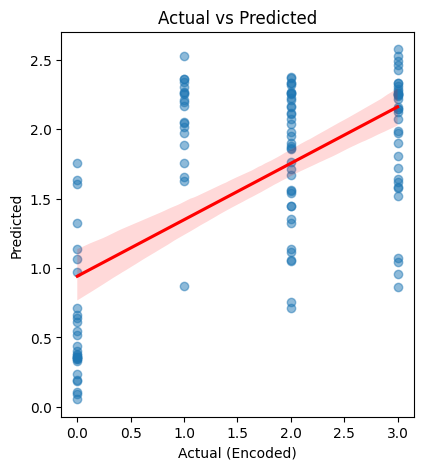

In [48]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Actual vs Predicted")
plt.xlabel("Actual (Encoded)")
plt.ylabel("Predicted")

## 10. VISUALIZATION 2: FEATURE IMPORTANCE

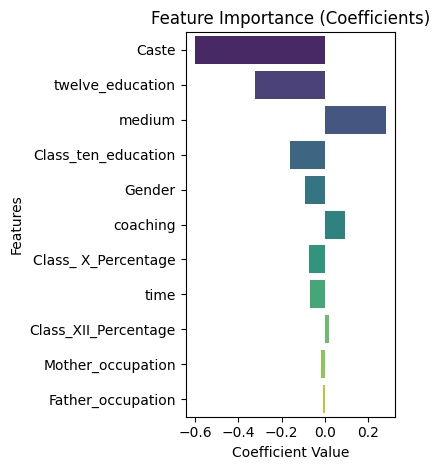

In [49]:
importance = lr_model.coef_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df["AbsImportance"] = feature_importance_df["Importance"].abs()
feature_importance_df = feature_importance_df.sort_values(
    by="AbsImportance",
    ascending=False
)

plt.subplot(1, 2, 2)
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df,
    hue="Feature",
    palette="viridis",
    legend=False
)
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# MILESTONE 3: TRAINING LOOP & METRICS

In [50]:
model = LinearRegression()

print("\nStarting Iterative Training Loop (5-Folds)...")

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

for i, score in enumerate(cv_scores):
    print(f"Iteration {i + 1} Progress: R-squared = {score:.4f}")


Starting Iterative Training Loop (5-Folds)...
Iteration 1 Progress: R-squared = -1.5865
Iteration 2 Progress: R-squared = 0.0000
Iteration 3 Progress: R-squared = -1.3471
Iteration 4 Progress: R-squared = -0.0459
Iteration 5 Progress: R-squared = -32.3905


## FINAL MODEL FITTING

In [51]:
model.fit(X_train, y_train)
print("\nFinal Training Phase Completed.")


Final Training Phase Completed.


## GENERATE PREDICTIONS & CALCULATE METRICS

In [52]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n============================================================")
print("MILESTONE 3 RESULTS")
print("============================================================")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Final R-squared Score: {r2:.4f}")


MILESTONE 3 RESULTS
Mean Squared Error (MSE): 0.7706
Final R-squared Score: 0.3999


## VISUALIZE TRAINING PROGRESS AND RESULTS

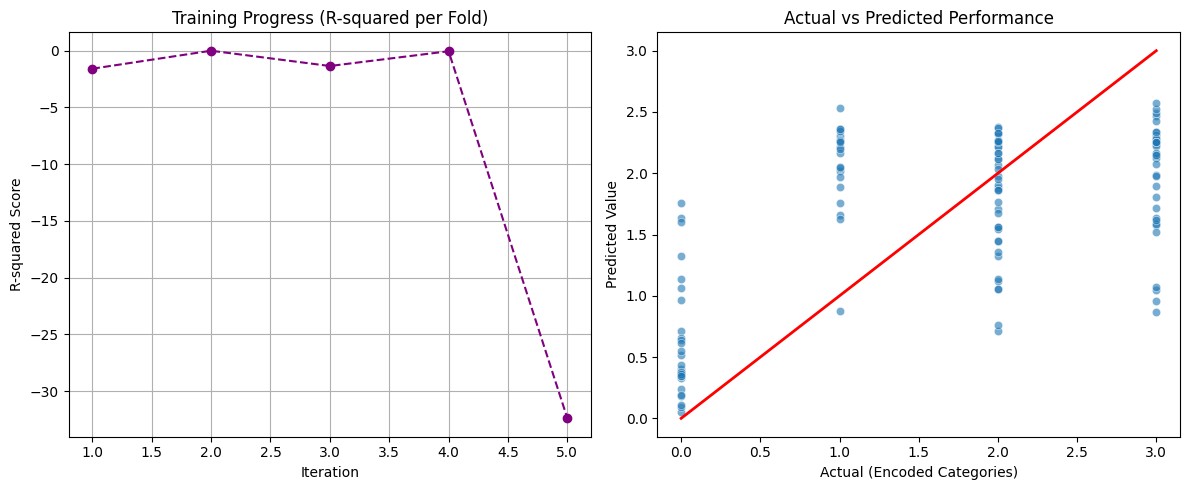

In [53]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 6), cv_scores, marker="o", linestyle="--", color="purple")
plt.title("Training Progress (R-squared per Fold)")
plt.xlabel("Iteration")
plt.ylabel("R-squared Score")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    lw=2
)
plt.title("Actual vs Predicted Performance")
plt.xlabel("Actual (Encoded Categories)")
plt.ylabel("Predicted Value")

plt.tight_layout()
plt.show()

# MILESTONE 4: MODEL OPTIMIZATION
## Focus: Reducing Overfitting

In [54]:
print("\n============================================================")
print("MILESTONE 4: MODEL OPTIMIZATION")
print("============================================================")

# Use original cleaned dataset, not label encoded version
df_m4 = df_original.copy()

X_m4 = df_m4.drop("Performance", axis=1)
y_m4 = df_m4["Performance"]

print("\nTarget class distribution:")
print(y_m4.value_counts())


MILESTONE 4: MODEL OPTIMIZATION

Target class distribution:
Performance
Good         194
Vg           178
Average      152
Excellent     98
Name: count, dtype: int64


## TRAIN-TEST SPLIT FOR MILESTONE 4

In [55]:
X_train_m4, X_test_m4, y_train_m4, y_test_m4 = train_test_split(
    X_m4,
    y_m4,
    test_size=0.2,
    random_state=42,
    stratify=y_m4
)

## PREPROCESSING

In [56]:
categorical_features = X_m4.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## PART A: BEFORE OPTIMIZATION
### Baseline Decision Tree Model

In [57]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

baseline_model.fit(X_train_m4, y_train_m4)

baseline_train_pred = baseline_model.predict(X_train_m4)
baseline_test_pred = baseline_model.predict(X_test_m4)

baseline_train_acc = accuracy_score(y_train_m4, baseline_train_pred)
baseline_test_acc = accuracy_score(y_test_m4, baseline_test_pred)

print("\n============================================================")
print("BEFORE OPTIMIZATION: BASELINE DECISION TREE")
print("============================================================")
print(f"Training Accuracy: {baseline_train_acc:.4f}")
print(f"Testing Accuracy: {baseline_test_acc:.4f}")
print(f"Overfitting Gap: {baseline_train_acc - baseline_test_acc:.4f}")

print("\nClassification Report Before Optimization:")
print(classification_report(y_test_m4, baseline_test_pred))


BEFORE OPTIMIZATION: BASELINE DECISION TREE
Training Accuracy: 0.9457
Testing Accuracy: 0.4320
Overfitting Gap: 0.5137

Classification Report Before Optimization:
              precision    recall  f1-score   support

     Average       0.69      0.80      0.74        30
   Excellent       0.35      0.45      0.39        20
        Good       0.32      0.23      0.27        39
          Vg       0.33      0.33      0.33        36

    accuracy                           0.43       125
   macro avg       0.42      0.45      0.43       125
weighted avg       0.42      0.43      0.42       125



## PART B: AFTER OPTIMIZATION
### Tuned Decision Tree using GridSearchCV

In [58]:
optimized_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

param_grid = {
    "classifier__max_depth": [2, 3, 4, 5, 6, 8],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 6, 8],
    "classifier__criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    optimized_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_m4, y_train_m4)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Gender',
                                                                          'Caste',
                                                                          'coaching',
                                                                          'time',
                                                                          'Class_ten_education',
                                                                          'twelve_education',
                                                                          'medium',
                                                                          'Class_ '
                                                                          'X_Percentage',
                                                                          'Class_XII_Percentage',
                                                                          'Father_occupation',
                                                                          'Mother_occupation'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [2, 3, 4, 5, 6, 8],
                         'classifier__min_samples_leaf': [1, 2, 4, 6, 8],
                         'classifier__min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [59]:
best_model = grid_search.best_estimator_

optimized_train_pred = best_model.predict(X_train_m4)
optimized_test_pred = best_model.predict(X_test_m4)

optimized_train_acc = accuracy_score(y_train_m4, optimized_train_pred)
optimized_test_acc = accuracy_score(y_test_m4, optimized_test_pred)

print("\n============================================================")
print("AFTER OPTIMIZATION: TUNED DECISION TREE")
print("============================================================")
print("Best Parameters:", grid_search.best_params_)
print(f"Training Accuracy: {optimized_train_acc:.4f}")
print(f"Testing Accuracy: {optimized_test_acc:.4f}")
print(f"Overfitting Gap: {optimized_train_acc - optimized_test_acc:.4f}")

print("\nClassification Report After Optimization:")
print(classification_report(y_test_m4, optimized_test_pred))


AFTER OPTIMIZATION: TUNED DECISION TREE
Best Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 20}
Training Accuracy: 0.5252
Testing Accuracy: 0.5280
Overfitting Gap: -0.0028

Classification Report After Optimization:
              precision    recall  f1-score   support

     Average       0.67      0.87      0.75        30
   Excellent       0.62      0.25      0.36        20
        Good       0.42      0.26      0.32        39
          Vg       0.46      0.69      0.56        36

    accuracy                           0.53       125
   macro avg       0.54      0.52      0.50       125
weighted avg       0.52      0.53      0.50       125



## PART C: COMPARE BEFORE AND AFTER OPTIMIZATION

In [60]:
results = pd.DataFrame({
    "Model": ["Before Optimization", "After Optimization"],
    "Training Accuracy": [baseline_train_acc, optimized_train_acc],
    "Testing Accuracy": [baseline_test_acc, optimized_test_acc],
    "Overfitting Gap": [
        baseline_train_acc - baseline_test_acc,
        optimized_train_acc - optimized_test_acc
    ]
})

print("\n============================================================")
print("MODEL COMPARISON")
print("============================================================")
print(results)


MODEL COMPARISON
                 Model  Training Accuracy  Testing Accuracy  Overfitting Gap
0  Before Optimization           0.945674             0.432         0.513674
1   After Optimization           0.525151             0.528        -0.002849


## SAVE RESULTS

In [61]:
os.makedirs("results/milestone4", exist_ok=True)

results.to_csv("results/milestone4/milestone4_accuracy_comparison.csv", index=False)

## VISUALIZATION 1: ACCURACY COMPARISON

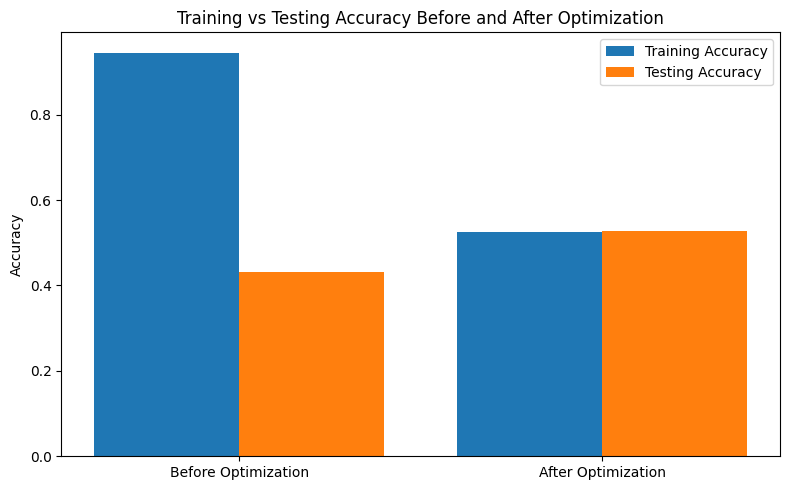

In [62]:
plt.figure(figsize=(8, 5))

x = range(len(results["Model"]))

plt.bar(x, results["Training Accuracy"], width=0.4, label="Training Accuracy")
plt.bar(
    [i + 0.4 for i in x],
    results["Testing Accuracy"],
    width=0.4,
    label="Testing Accuracy"
)

plt.xticks([i + 0.2 for i in x], results["Model"])
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Before and After Optimization")
plt.legend()
plt.tight_layout()

plt.savefig("results/milestone4/milestone4_accuracy_comparison.png")
plt.show()

## VISUALIZATION 2: OVERFITTING GAP

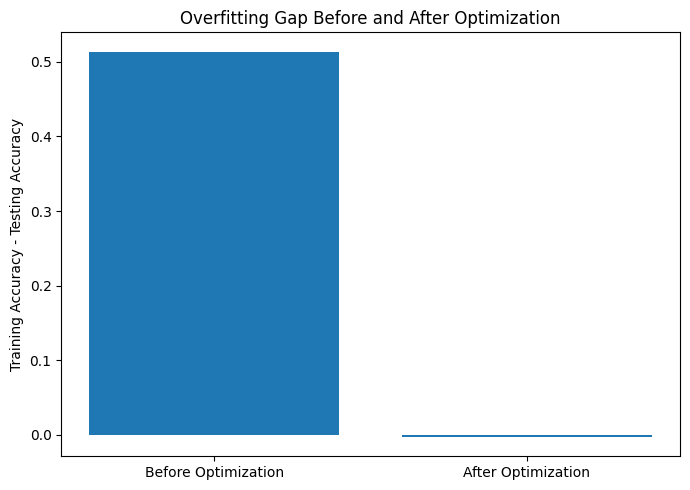

In [63]:
plt.figure(figsize=(7, 5))

plt.bar(results["Model"], results["Overfitting Gap"])
plt.ylabel("Training Accuracy - Testing Accuracy")
plt.title("Overfitting Gap Before and After Optimization")
plt.tight_layout()

plt.savefig("results/milestone4/milestone4_overfitting_gap.png")
plt.show()

## VISUALIZATION 3: CONFUSION MATRIX

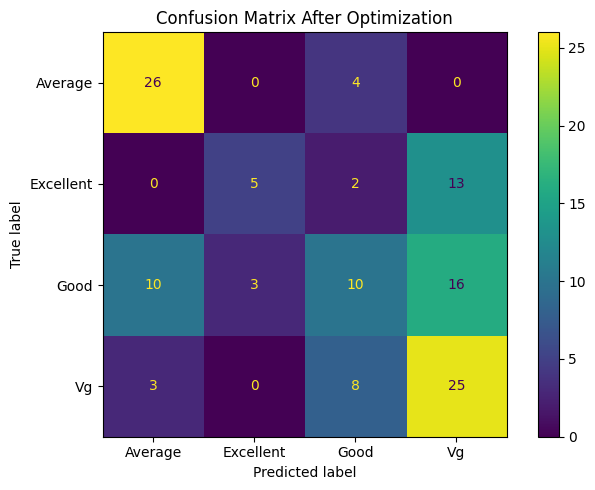


ALL MILESTONES COMPLETED SUCCESSFULLY
Milestone 4 result files are saved in the 'results' folder.


In [64]:
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_m4,
    y_test_m4,
    ax=ax
)

plt.title("Confusion Matrix After Optimization")
plt.tight_layout()

plt.savefig("results/milestone4/milestone4_confusion_matrix.png")
plt.show()

print("\n============================================================")
print("ALL MILESTONES COMPLETED SUCCESSFULLY")
print("============================================================")
print("Milestone 4 result files are saved in the 'results' folder.")

# MILESTONE 5: FINAL MODEL EVALUATION

In [65]:
output_dir = "results/milestone5"
os.makedirs(output_dir, exist_ok=True)

print("\n======================================================")
print("MILESTONE 5 : FINAL MODEL EVALUATION")
print("========================================================")


MILESTONE 5 : FINAL MODEL EVALUATION


## TEST METRICS

In [ ]:
final_test_accuracy = accuracy_score(y_test_m4, optimized_test_pred)
print(f"Final Testing Accuracy : {final_test_accuracy:.4f}")

print("\nClassification Report:")
final_report = classification_report(
    y_test_m4,
    optimized_test_pred,
    output_dict=True,
    zero_division=0
)

final_report_df = pd.DataFrame(final_report).transpose()
print(final_report_df)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=final_report_df.round(3).values,
    colLabels=final_report_df.columns,
    rowLabels=final_report_df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.2)

plt.title("Final Classification Report")
plt.savefig(
    os.path.join(output_dir, "Milestone_5_Classification_Report.png"),
    bbox_inches="tight"
)
plt.show()

## ACTUAL VS PREDICTED COMPARISON

In [ ]:
result_comparison_df = pd.DataFrame({
    "Actual Result": y_test_m4.values,
    "Predicted Result": optimized_test_pred
})

print("\nActual vs Predicted Result:")
print(result_comparison_df.head(20))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=result_comparison_df.head(20).values,
    colLabels=result_comparison_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.2)

plt.title("Actual vs Predicted Results")
plt.savefig(
    os.path.join(output_dir, "Milestone_5_Actual_vs_Predicted.png"),
    bbox_inches="tight"
)
plt.show()

## FINAL METRICS SUMMARY

In [ ]:
final_summary_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        final_report["accuracy"],
        final_report["weighted avg"]["precision"],
        final_report["weighted avg"]["recall"],
        final_report["weighted avg"]["f1-score"]
    ]
})

plt.figure(figsize=(6, 5))

plt.bar(
    final_summary_df["Metric"],
    final_summary_df["Value"]
)

plt.ylabel("Score")
plt.title("Final Evaluation Metric")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "Milestone_5_Final_Metrics_Graph.png")
)
plt.show()

## FINAL CONFUSION MATRIX

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_m4,
    y_test_m4,
    ax=ax
)

plt.title("Milestone 5 Final Confusion Matrix")
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "Milestone_5_Final_Confusion_Matrix.png")
)
plt.show()

print("\nMilestone 5 completed successfully.")
print(f"Final evaluation files saved in:\n{output_dir}")